# Studying phase oscillators on hypergraphs using multivariate information theory

Layout
1. Define the model settings and explain expected behaviour
2. Explore sub-, super-, and critical states of the dynamics
3. Explore information metrics accordingly

**Define functions and imports**

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgi
import itertools
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

In [ ]:
def kuramoto_xgi(t, theta, omega, K2, K3, H, N):
    H_int = xgi.convert_labels_to_integers(H, "label")
    links = H_int.edges.filterby("size", 2).members()
    triangles = H_int.edges.filterby("size", 3).members()
    dtheta = np.zeros(N)
    r1 = np.zeros(N, dtype=complex)
    r2 = np.zeros(N, dtype=complex)
    for i, j in links:
        r1[i] += np.exp(1j * theta[j])
        r1[j] += np.exp(1j * theta[i])
    for i, j, k in triangles:
        r2[i] += np.exp(2j * theta[j] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[j])
        r2[j] += np.exp(2j * theta[i] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[i])
        r2[k] += np.exp(2j * theta[i] - 1j * theta[j]) + np.exp(2j * theta[j] - 1j * theta[i])
    for i in range(N):
        dtheta[i] = omega[i] + K2 * np.imag(r1[i] * np.exp(-1j * theta[i])) + K3 * np.imag(r2[i] * np.exp(-1j * theta[i]))
    return dtheta

def simulate_xgi_time_series(N, K, K2K3_ratio, T=10, dt=0.01, n_sim=4):
    # generate fully connected hypergraph of N nodes
    H = xgi.Hypergraph()
    nodes = list(range(N))
    H.add_nodes_from(nodes)
    max_order = 3
    
    for k in range(1, max_order + 1):
        for edge in itertools.combinations(nodes, k):
            H.add_edge(edge)
    
    t_eval = np.arange(0, T, dt)
    K2 = K2K3_ratio*K
    K3 = (1-K2K3_ratio)*K

    r_all = []
    freq_dfs = []

    for _ in range(n_sim):
        omega = np.random.normal(0, 1, N)
        theta0 = np.random.uniform(0, 2*np.pi, N)

        sol = solve_ivp(kuramoto_xgi, [0, T], theta0, t_eval=t_eval, args=(omega, K2, K3, H, N))
        theta_ts = sol.y.T

        # Instantaneous frequencies
        freqs = np.gradient(theta_ts, axis=0) / dt
        freq_df = pd.DataFrame(freqs, index=t_eval, columns=[f"osc_{i}" for i in range(N)])
        freq_dfs.append(freq_df)

        # Order parameter
        r = np.abs(np.mean(np.exp(1j * theta_ts), axis=1))
        r_all.append(r)

    r_all = np.array(r_all)
    return t_eval, r_all, freq_dfs

def estimate_critical_coupling(K_values, r_avg_values):
    # Fit a sigmoid function to estimate the critical value
    def sigmoid(K, L, x0, k, b):
        return L / (1 + np.exp(-k * (K - x0))) + b

    # Convert data to numpy arrays
    K_values = np.array(K_values)
    r_avg_values = np.array(r_avg_values)

    # Define safe bounds with buffer
    eps = 1e-3  # small buffer to avoid hitting bounds
    lb = [0, K_values.min() + eps, 0, 0]
    ub = [2, K_values.max() - eps, 100, 1]

    # Safe initial guess within bounds
    p0 = [1.0, K_values.mean(), 10.0, 0.0]

    # Fit sigmoid
    popt, _ = curve_fit(sigmoid, K_values, r_avg_values, p0=p0, bounds=(lb, ub))

    # Extract params and compute fitted curve
    L, x0, k, b = popt
    K_fine = np.linspace(K_values.min(), K_values.max(), 500)
    r_fit = sigmoid(K_fine, *popt)

    # Compute gradient and check against threshold
    r_grad = np.gradient(r_fit, K_fine)
    max_grad = np.max(r_grad)
    K_max_grad = K_fine[np.argmax(r_grad)]

    slope_threshold = np.tan(np.deg2rad(70))  # ≈ 0.577

    if max_grad >= slope_threshold:
        K_max_grad = K_max_grad
    else:
        K_max_grad = None
    return K_fine, r_fit, K_max_grad


**1. Define model settings**

In [62]:
# System settings
N = 10
K = 0.5
K2K3_ratio = .5
T = 10 
dt = 0.01
n_sim = 100

In [63]:
# Generate timeseries
t_eval, r_all, freq_dfs = simulate_xgi_time_series(N, K, K2K3_ratio, T, dt, n_sim)

Verify dynamics

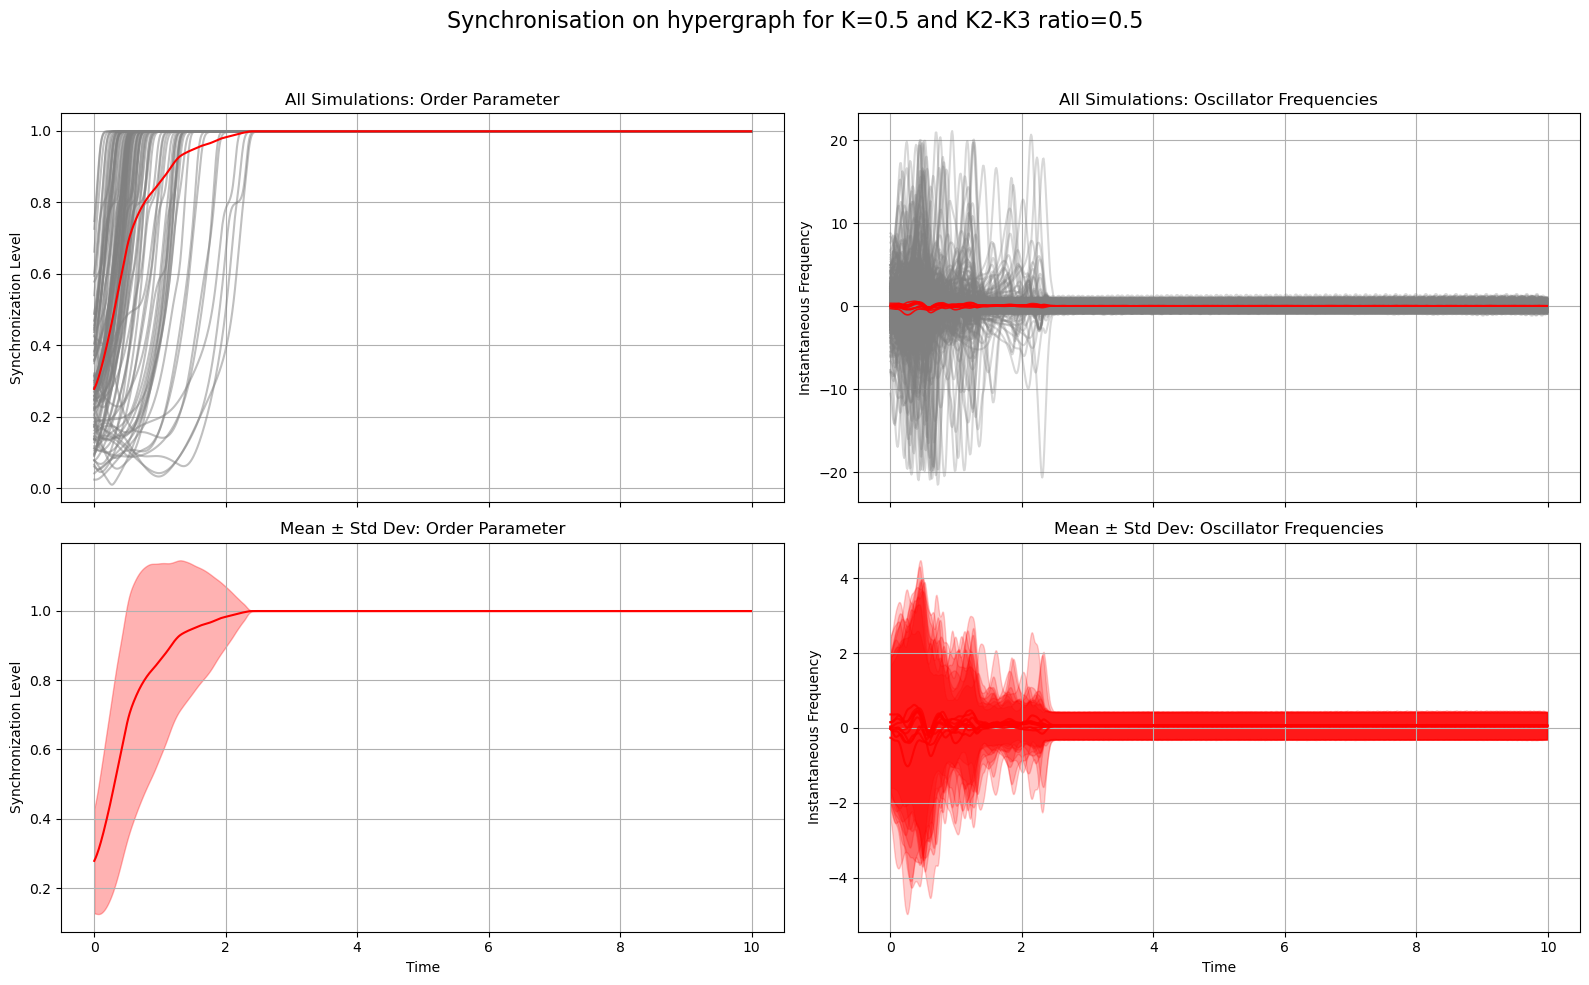

In [64]:
# Compute statistics
r_avg = np.mean(r_all, axis=0)
r_std = np.std(r_all, axis=0)

freq_array = np.stack([df.values for df in freq_dfs], axis=0)
freq_avg = np.mean(freq_array, axis=0)  # shape (len(t_eval), N)
freq_std = np.std(freq_array, axis=0)

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Suptitle
fig.suptitle(f'Synchronisation on hypergraph for K={K} and K2-K3 ratio={K2K3_ratio}', fontsize=16)

# --- Top left: All simulations - Order parameter ---
for r in r_all:
    axs[0, 0].plot(t_eval, r, color='grey', alpha=0.5)
axs[0, 0].plot(t_eval, r_avg, color='red', label='Average Order Parameter')
axs[0, 0].set_title("All Simulations: Order Parameter")
axs[0, 0].set_ylabel("Synchronization Level")
axs[0, 0].grid(True)

# --- Top right: All simulations - Frequencies ---
for freq_df in freq_dfs:
    for col in freq_df.columns:
        axs[0, 1].plot(freq_df.index, freq_df[col], color='grey', alpha=0.3)
for i in range(N):
    axs[0, 1].plot(t_eval, freq_avg[:, i], color='red', alpha=0.9, linewidth=1.2)
axs[0, 1].set_title("All Simulations: Oscillator Frequencies")
axs[0, 1].set_ylabel("Instantaneous Frequency")
axs[0, 1].grid(True)

# --- Bottom left: Mean ± Std Dev - Order parameter ---
axs[1, 0].plot(t_eval, r_avg, color='red', label='Mean Order Parameter')
axs[1, 0].fill_between(t_eval, r_avg - r_std, r_avg + r_std, color='red', alpha=0.3, label='±1 Std Dev')
axs[1, 0].set_title("Mean ± Std Dev: Order Parameter")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("Synchronization Level")
axs[1, 0].grid(True)

# --- Bottom right: Mean ± Std Dev - Frequencies ---
for i in range(N):
    axs[1, 1].plot(t_eval, freq_avg[:, i], color='red', alpha=0.8)
    axs[1, 1].fill_between(t_eval,
                           freq_avg[:, i] - freq_std[:, i],
                           freq_avg[:, i] + freq_std[:, i],
                           color='red',
                           alpha=0.2)
axs[1, 1].set_title("Mean ± Std Dev: Oscillator Frequencies")
axs[1, 1].set_xlabel("Time")
axs[1, 1].set_ylabel("Instantaneous Frequency")
axs[1, 1].grid(True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Explore order parameter phase transition

In [182]:
# System settings
N = 10
K = 0.1
K2K3_ratio = 1
T = 10 
dt = 0.01
n_sim = 10

In [186]:
# Run simulations
K_values = np.linspace(0.01, 0.4, 100)
r_avg_values = []
r_std_values = []

for K in K_values:
    t_eval, r_all, freq_dfs = simulate_xgi_time_series(N, K, K2K3_ratio, T, dt, n_sim)
    
    # Take the last value of r for each simulation
    r_final_values = r_all[:, -1]  # shape: (n_sim,)
    
    r_avg_values.append(np.mean(r_final_values))  # mean across simulations
    r_std_values.append(np.std(r_final_values))   # std across simulations

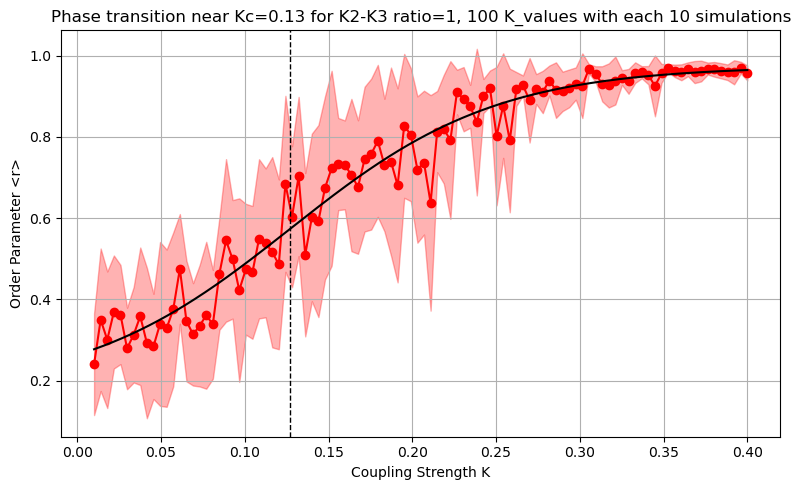

In [188]:
K_fine, r_fit, Kc_estimation = estimate_critical_coupling(K_values, r_avg_values)
r_avg_values = np.array(r_avg_values)
r_std_values = np.array(r_std_values)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_values, r_avg_values, color='red', label='Mean Order Parameter')
plt.plot(K_values, r_avg_values, 'ro', label='Data')
plt.plot(K_fine, r_fit, 'black', label='Sigmoid fit')
plt.fill_between(K_values,
                 r_avg_values - r_std_values,
                 r_avg_values + r_std_values,
                 color='red', alpha=0.3, label='±1 Std Dev')
if Kc_estimation != None:
    plt.axvline(Kc_estimation, color='black', linestyle='--', linewidth=1, label='Max Gradient')
plt.xlabel('Coupling Strength K')
plt.ylabel('Order Parameter <r>')
plt.title(f'Phase transition near Kc={Kc_estimation:.2f} for K2-K3 ratio={K2K3_ratio}, {len(K_values)} K_values with each {n_sim} simulations')
plt.grid(True)
plt.tight_layout()
plt.show()

Explore critical value against high-orderness

In [194]:
# System settings
N = 10
K = 0.1
K2K3_ratio = 1
T = 10 
dt = 0.01
n_sim = 4

In [195]:
Kc_dict = {}

# Run simulations for range of coupling ratios
for K2K3_ratio in np.linspace(0, 1, 100):

    K_values = np.linspace(0.01, 0.4, 10)
    r_avg_values = []
    r_std_values = []

    for K in K_values:
        t_eval, r_all, freq_dfs = simulate_xgi_time_series(N, K, K2K3_ratio, T, dt, n_sim)
        
        # Take the last value of r for each simulation
        r_final_values = r_all[:, -1]  # shape: (n_sim,)
        
        r_avg_values.append(np.mean(r_final_values))  # mean across simulations
        r_std_values.append(np.std(r_final_values))   # std across simulations

    Kc_estimation = estimate_critical_coupling(K_values, r_avg_values)[2]
    Kc_dict[K2K3_ratio] = Kc_estimation

    # slope_threshold = np.tan(np.deg2rad(70))

    # if max_grad >= slope_threshold:
    #     Kc_dict[K2K3_ratio] = K_max_grad

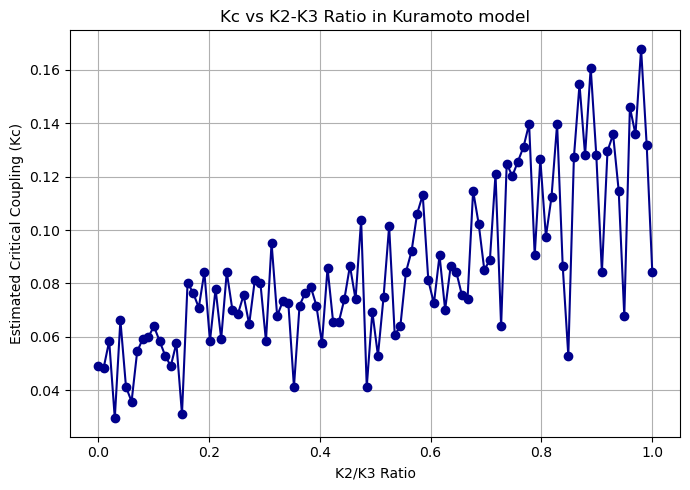

In [199]:
# Filter out None or NaN values
filtered_dict = {k: v for k, v in Kc_dict.items() if v is not None}

# Extract keys and values
ratios = list(filtered_dict.keys())
Kc_values = list(filtered_dict.values())

# Plot
plt.figure(figsize=(7, 5))
plt.plot(ratios, Kc_values, marker='o', linestyle='-', color='darkblue')
plt.xlabel('K2/K3 Ratio')
plt.ylabel('Estimated Critical Coupling (Kc)')
plt.title('Kc vs K2-K3 Ratio in Kuramoto model')
plt.grid(True)
plt.tight_layout()
plt.show()


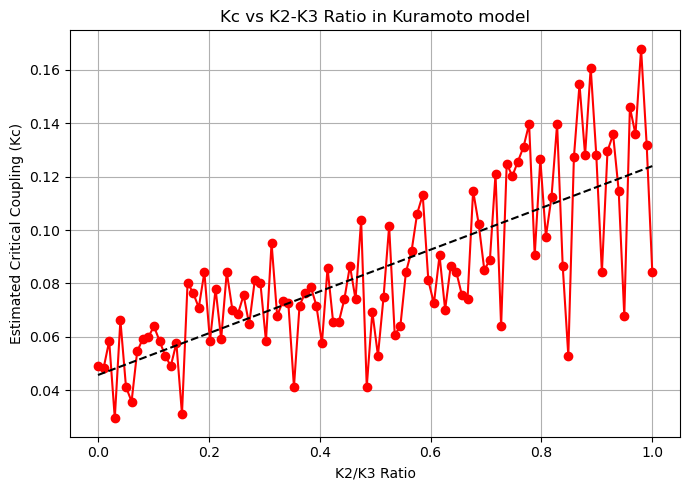

In [204]:
import numpy as np
import matplotlib.pyplot as plt

# Filter out None or NaN values
filtered_dict = {k: v for k, v in Kc_dict.items() if v is not None and not np.isnan(v)}

# Extract keys and values
ratios = np.array(list(filtered_dict.keys()))
Kc_values = np.array(list(filtered_dict.values()))

# Linear fit
coeffs = np.polyfit(ratios, Kc_values, 1)
linear_fit = np.poly1d(coeffs)
fit_values = linear_fit(ratios)

# Calculate R^2
ss_res = np.sum((Kc_values - fit_values) ** 2)
ss_tot = np.sum((Kc_values - np.mean(Kc_values)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(ratios, Kc_values, marker='o', linestyle='-', color='red', label='Data')
plt.plot(ratios, fit_values, color='black', linestyle='--', label=f'Linear fit\n$R^2$ = {r_squared:.3f}')
plt.xlabel('K2/K3 Ratio')
plt.ylabel('Estimated Critical Coupling (Kc)')
plt.title('Kc vs K2-K3 Ratio in Kuramoto model')
plt.grid(True)
plt.tight_layout()
plt.show()


Explore behaviour of multivariate information metrics